In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
sns.set_style('whitegrid')
path = r"A:\\Programs\\M_VS_Code_projects\\jupyter\\IPYNB-machine-learning\\lects\\student-scores.csv"
df = pd.read_csv(path)
df

,Unnamed: 0,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,No,Yes
0,0,1,340.0,116.0,1518.0,1.0,-0.433184,3,0.0,27,1,73,81,93,97,63,80,87,1.0,0.0
1,1,2,114.0,569.0,477.0,0.0,-0.433184,2,0.0,47,0,90,86,96,100,90,88,90,1.0,0.0
2,2,3,423.0,12.0,1888.0,0.0,-0.433184,9,1.0,13,0,81,97,95,96,65,77,94,0.0,1.0
3,3,4,412.0,129.0,1829.0,0.0,-0.433184,5,0.0,3,0,71,74,88,80,89,63,86,1.0,0.0
4,4,5,34.0,104.0,143.0,1.0,-0.433184,5,0.0,10,1,84,77,65,65,80,74,76,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,1996,5.0,534.0,18.0,1.0,-0.433184,2,0.0,30,1,83,77,84,73,75,84,82,1.0,0.0
1996,1996,1997,419.0,240.0,1856.0,1.0,-0.433184,2,0.0,20,1,89,65,73,80,87,67,73,1.0,0.0
1997,1997,1998,287.0,157.0,1232.0,0.0,-0.433184,5,0.0,14,0,97,85,63,93,68,94,78,1.0,0.0
1998,1998,1999,65.0,142.0,265.0,0.0,2.308487,10,1.0,5,0,51,96,72,89,95,88,75,0.0,1.0


<p>
Суть методов понижения размерности: поиск более важные осей координат, которые наилучшим образом описывают наши данные.

Метод №1: РСА (Метод главных компонент)

РСА работает по следующему принципу:
<ol>
    <li>Он ищет такое положение фонарика, чтобы тень была максимально информативной (чтобы было видно, что человечек развел руки в стороны, а не стоял по стойке смирно).</li>
    <li>Он проецирует все точки на эту плоскость.</li>
</ol>
РСА находит направление, вдоль которого данные сильнее всего разбросаны. Это и есть самая важная ось. Потом находит вторую ось, перпендикулярную первой (чтобы не повторяться), и так далее. Мусорные оси мы просто отбрасываем.
</p>

In [4]:
df[['first_name', 'gender', 'math_score', 'career_aspiration']].head()

,first_name,gender,math_score,career_aspiration
0,340.0,1.0,73,1
1,114.0,0.0,90,0
2,423.0,0.0,81,0
3,412.0,0.0,71,0
4,34.0,1.0,84,1


In [5]:
df.shape

(2000, 20)

In [6]:
df.columns.tolist()

['Unnamed: 0',
 'id',
 'first_name',
 'last_name',
 'email',
 'gender',
 'part_time_job',
 'absence_days',
 'extracurricular_activities',
 'weekly_self_study_hours',
 'career_aspiration',
 'math_score',
 'history_score',
 'physics_score',
 'chemistry_score',
 'biology_score',
 'english_score',
 'geography_score',
 'No',
 'Yes']

<p>
Дисперсия в математике - это мера разброса значений случайной величины относительно её математического ожидания. Простыми словами, дисперсия показывает, насколько далеко значения в наборе данных распространены вокруг среднего значения.
</p>

In [7]:
subject_features = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
# Признаки - поведение
behavior_features = ['absence_days', 'weekly_self_study_hours']
df[subject_features + behavior_features].isnull().sum()

math_score                 0
history_score              0
physics_score              0
chemistry_score            0
biology_score              0
english_score              0
geography_score            0
absence_days               0
weekly_self_study_hours    0
dtype: int64

<p>Анализ оценок по предметам</p>

In [8]:
X_subjects = df[subject_features] # данные для анализа самих оценок

In [9]:
scaler_subjects = StandardScaler() # метод стандартизации данных
X_subjects_scaled = scaler_subjects.fit_transform(X_subjects) # стандартизирование наших данных

In [10]:
pca_subjects = PCA(n_components=2) # экземпляр класса PCA
X_subjects_pca = pca_subjects.fit_transform(X_subjects_scaled) # трансормация по PCA

In [11]:
df['Subject_PC1'] = X_subjects_pca[:, 0]
df['Subject_PC2'] = X_subjects_pca[:, 1]

<p>Объединенная дисперсия по предметам</p>

In [12]:
for i, ratio in enumerate(pca_subjects.explained_variance_ratio_):
    print(f'PC{i+1}: {ratio:.3f} ({ratio*100:.1f}%)')
print(f'Сумма первых двух компонент: {sum(pca_subjects.explained_variance_ratio_):.3f}')

PC1: 0.227 (22.7%)
PC2: 0.149 (14.9%)
Сумма первых двух компонент: 0.376


In [14]:
loadings_subjects = pd.DataFrame(
    pca_subjects.components_.T,
    columns=['PC1', 'PC2'],
    index=subject_features
)
print('Нагрузка признаков на компоненты (предметы):')
print(loadings_subjects.round(3))

Нагрузка признаков на компоненты (предметы):
                   PC1    PC2
math_score       0.418 -0.298
history_score    0.398 -0.447
physics_score    0.372  0.461
chemistry_score  0.403  0.097
biology_score    0.382  0.369
english_score    0.360 -0.456
geography_score  0.302  0.381


<p>Анализ поведенческих факторов</p>

In [15]:
X_behavior = df[behavior_features]

# Стандартизация
scaler_behavior = StandardScaler()
X_behavior_scaled = scaler_behavior.fit_transform(X_behavior)

In [16]:
# PCA (здесь мыможем взять все компоненты, тк их всего 2)
pca_behavior = PCA(n_components=2)
X_behavior_pca = pca_behavior.fit_transform(X_behavior_scaled)

df['Behavior_PC1'] = X_behavior_pca[:, 0]
df['Behavior_PC2'] = X_behavior_pca[:, 1]

<p>Объединенная дисперсия (поведение)</p>

In [17]:
print(f'PC1: {pca_behavior.explained_variance_ratio_[0]:.3f}')
print(f'PC2: {pca_behavior.explained_variance_ratio_[1]:.3f}')

PC1: 0.643
PC2: 0.357


In [18]:
loadings_behavior = pd.DataFrame(
    pca_behavior.components_.T,
    columns=['PC1', 'PC2'],
    index=behavior_features
)
print('Нагрузки признаков:')
print(loadings_behavior.round(3))

Нагрузки признаков:
                           PC1    PC2
absence_days             0.707  0.707
weekly_self_study_hours -0.707  0.707


<p>
Интерпритация:
PC1 отражает общую 'вовлеченность' (мало прогулов + много часов)
PC2 - контраст между прогулами и часами занятий
</p>

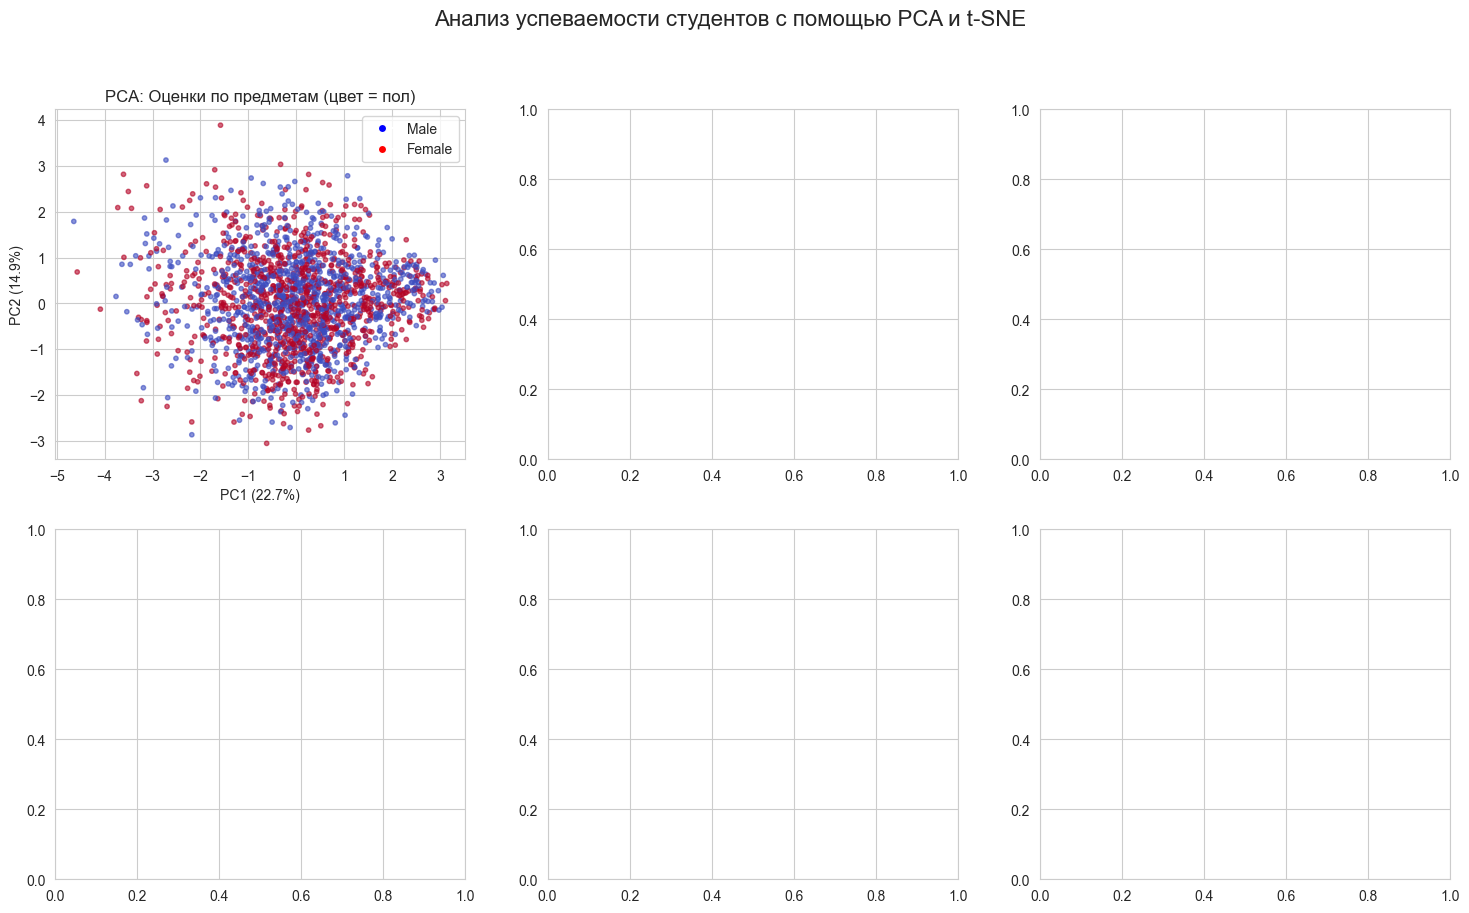

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ успеваемости студентов с помощью PCA и t-SNE', fontsize=16)
# График 1: PCA по предметам (раскраска по полу)
sc1 = axes[0, 0].scatter(df['Subject_PC1'], df['Subject_PC2'], 
                         c=pd.factorize(df['gender'])[0], cmap='coolwarm', alpha=0.6, s=10)
axes[0, 0].set_xlabel(f'PC1 ({pca_subjects.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca_subjects.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 0].set_title('PCA: Оценки по предметам (цвет = пол)')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='b', label='Male'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='r', label='Female')]
axes[0, 0].legend(handles=legend_elements, loc='upper right')